### Load all simulation complexes

Load all simulation complexes.


In [3]:
import os
from tqdm.notebook import tqdm
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt

ligand_name = "PDL"
simdir = "1lml_pdl_complex_scaled8"
data_dirname = "sys_prod"
data_dir = os.path.join(simdir, data_dirname)
xtc_file_1 = os.path.join(data_dir,  "prod_" + simdir + "_compact_compact.xtc")
xtc_file_2 = os.path.join(data_dir,  "prod_" + simdir + ".part0002_compact_compact.xtc")
top_file = os.path.join(data_dir, "prod_" + simdir + ".tpr")

Prepare protlig tpr selections for each complex (unless it already exists from old PP)

Now, prepare MDAnalysis universes for each complex

In [4]:
complex = mda.Universe(top_file, [xtc_file_1, xtc_file_2])

# Add bonds between the Palladium in the ligand and the co-ordinating nitrogens in the ligand
ligand = complex.select_atoms("resname PDL")
pd_atom = ligand.select_atoms("name PD* or name Pd*")

if len(pd_atom) > 0:
    pd_idx = pd_atom.indices[0]
    # Select nitrogens within 2.5 Angstroms of the Pd atom
    n_atoms = ligand.select_atoms(f"name N* and around 2.5 index {pd_idx}")
    
    if len(n_atoms) > 0:
        bonds = [(pd_idx, n_idx) for n_idx in n_atoms.indices]
        complex.add_TopologyAttr('bonds', bonds)
        print(f"Added bonds between Pd (index {pd_idx}) and {len(n_atoms)} coordinated N atoms (indices {n_atoms.indices})")

Added bonds between Pd (index 6898) and 4 coordinated N atoms (indices [6905 6906 6917 6918])


### Calculate all RMSD values and load in a dataframe

  0%|          | 0/4002 [00:00<?, ?it/s]

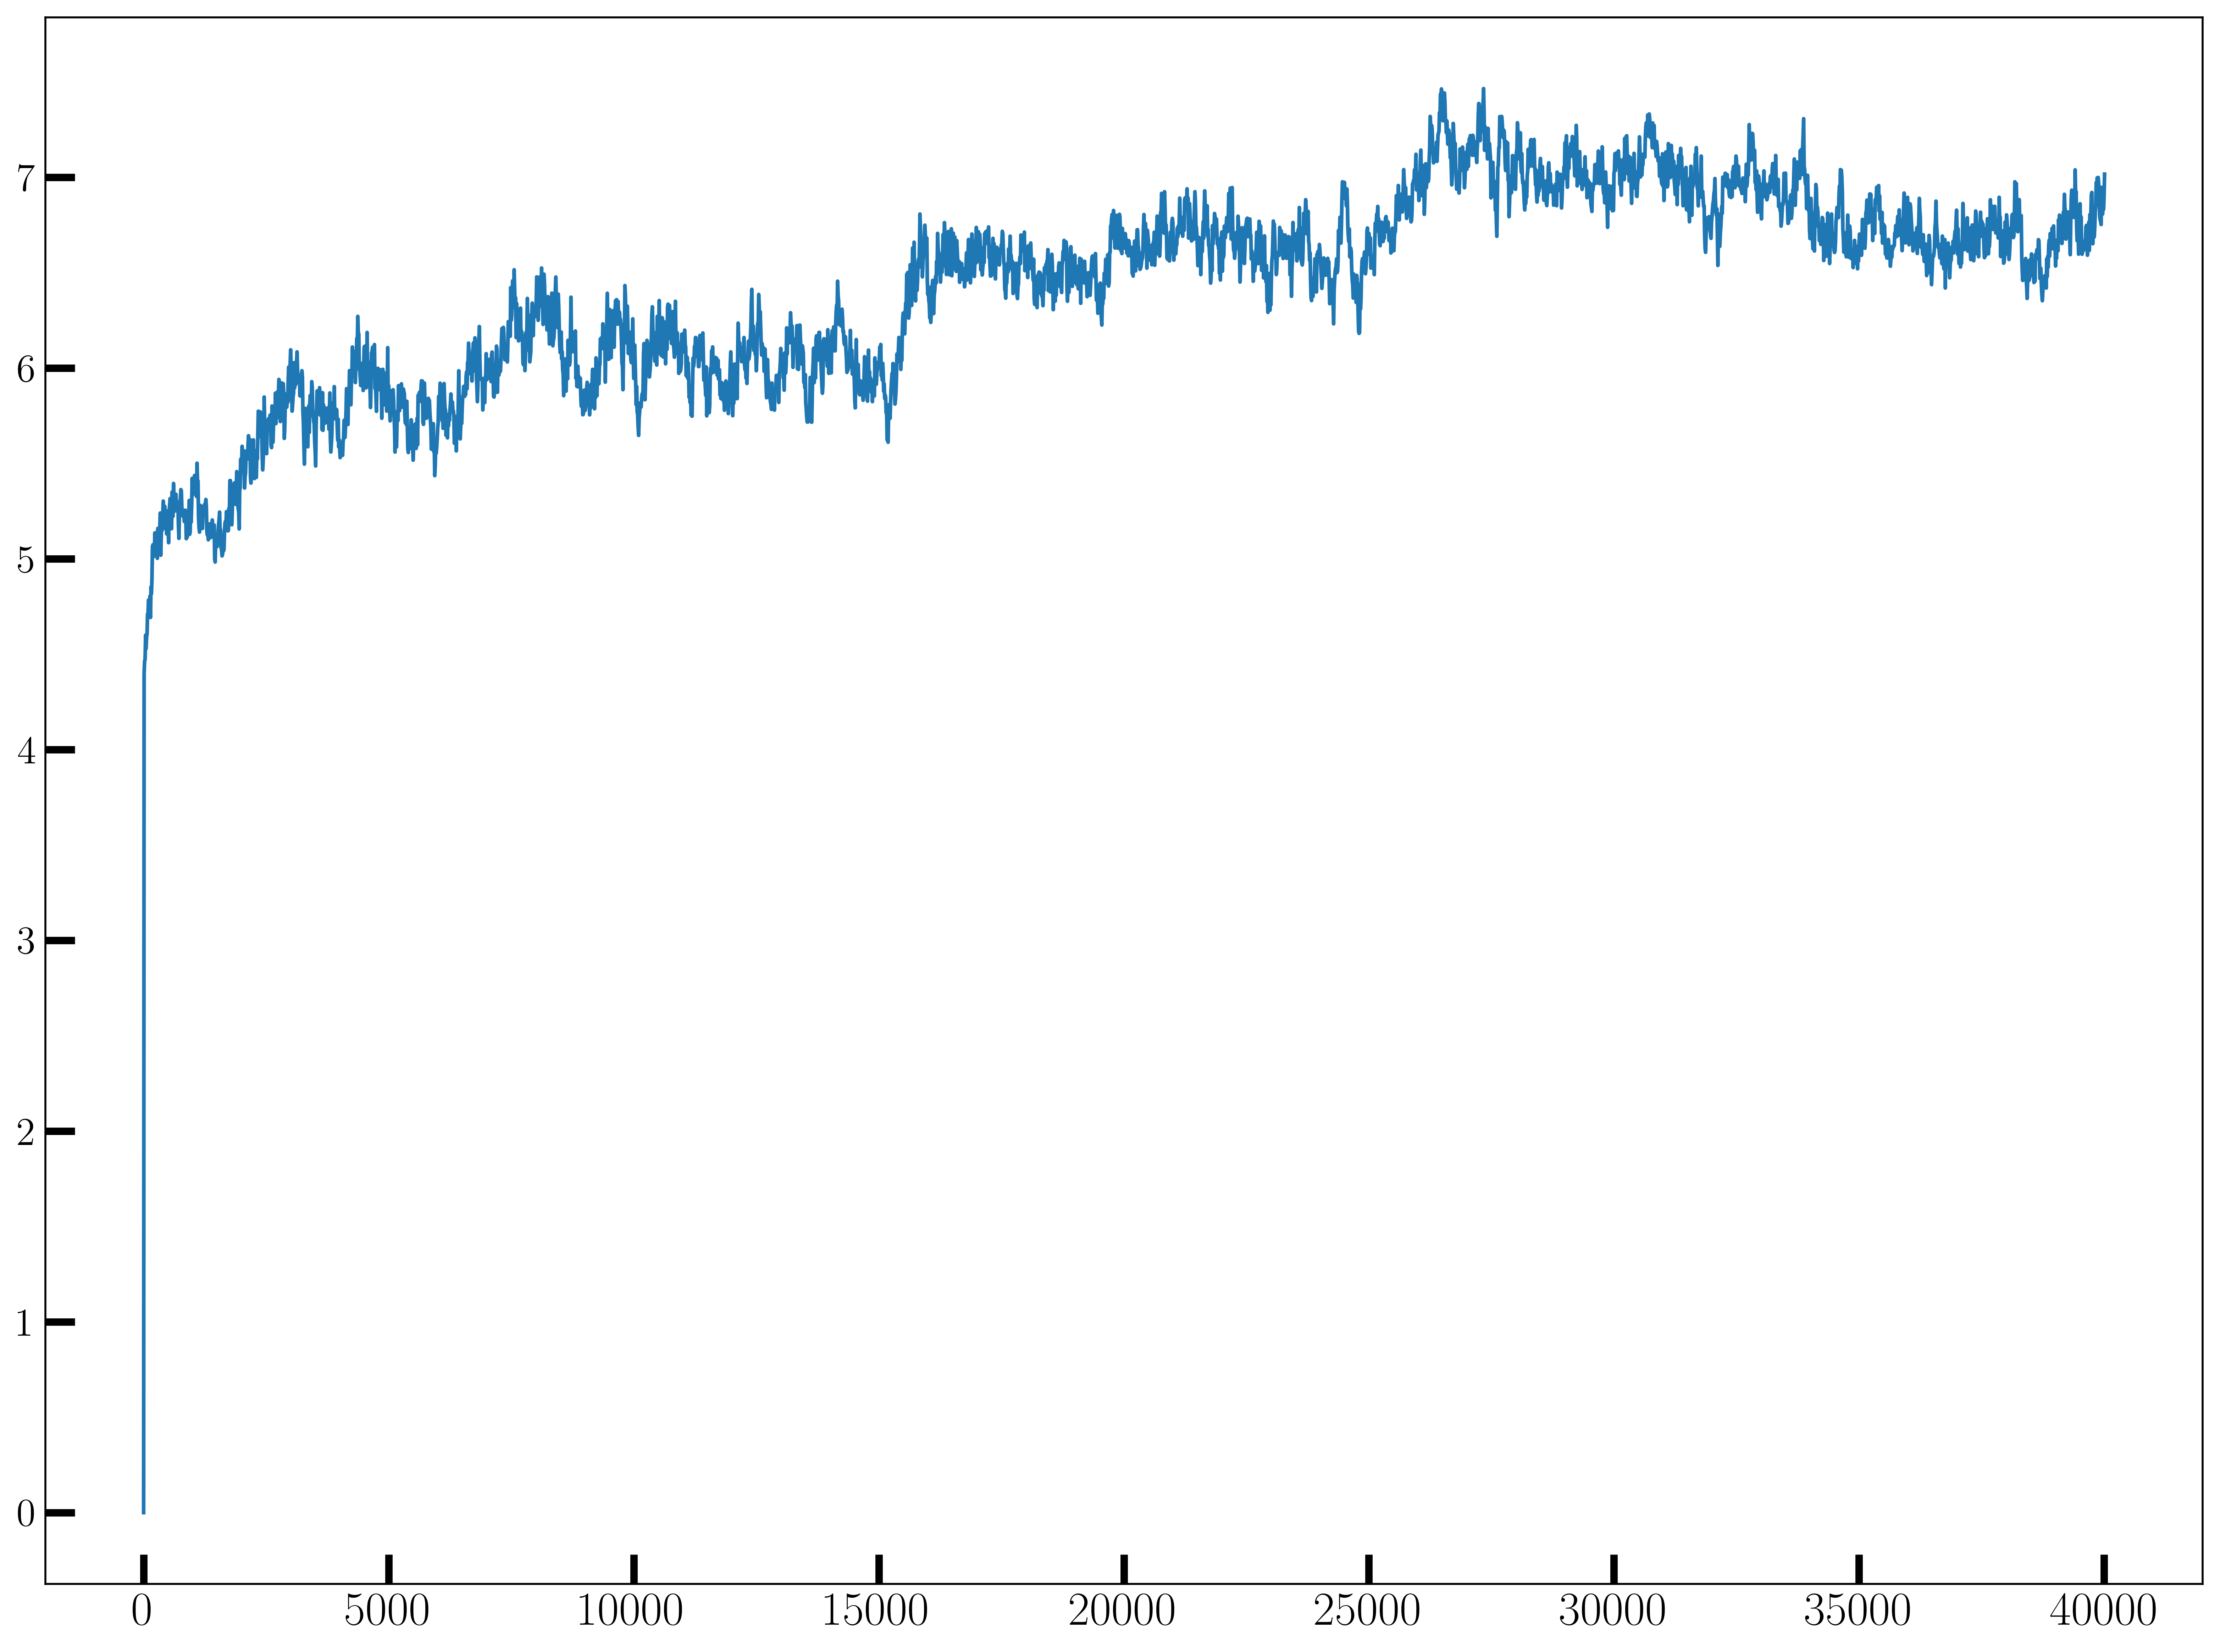

In [5]:
from MDAnalysis.analysis import rms
R = rms.RMSD(complex, complex, select='backbone', ref_frame=0)
R.run(verbose=True)
times = R.results.rmsd[:, 1]
rmsd = R.results.rmsd[:, 2]
plt.plot(times, rmsd)

In [6]:
# Put the rmsd data into a pandas dataframe
import pandas as pd
df = pd.DataFrame({'time': times, 'rmsd': rmsd})

### Calculate all RMSF and load in the previous pandas dataframe

  0%|          | 0/4002 [00:00<?, ?it/s]

<Axes: xlabel='resid'>

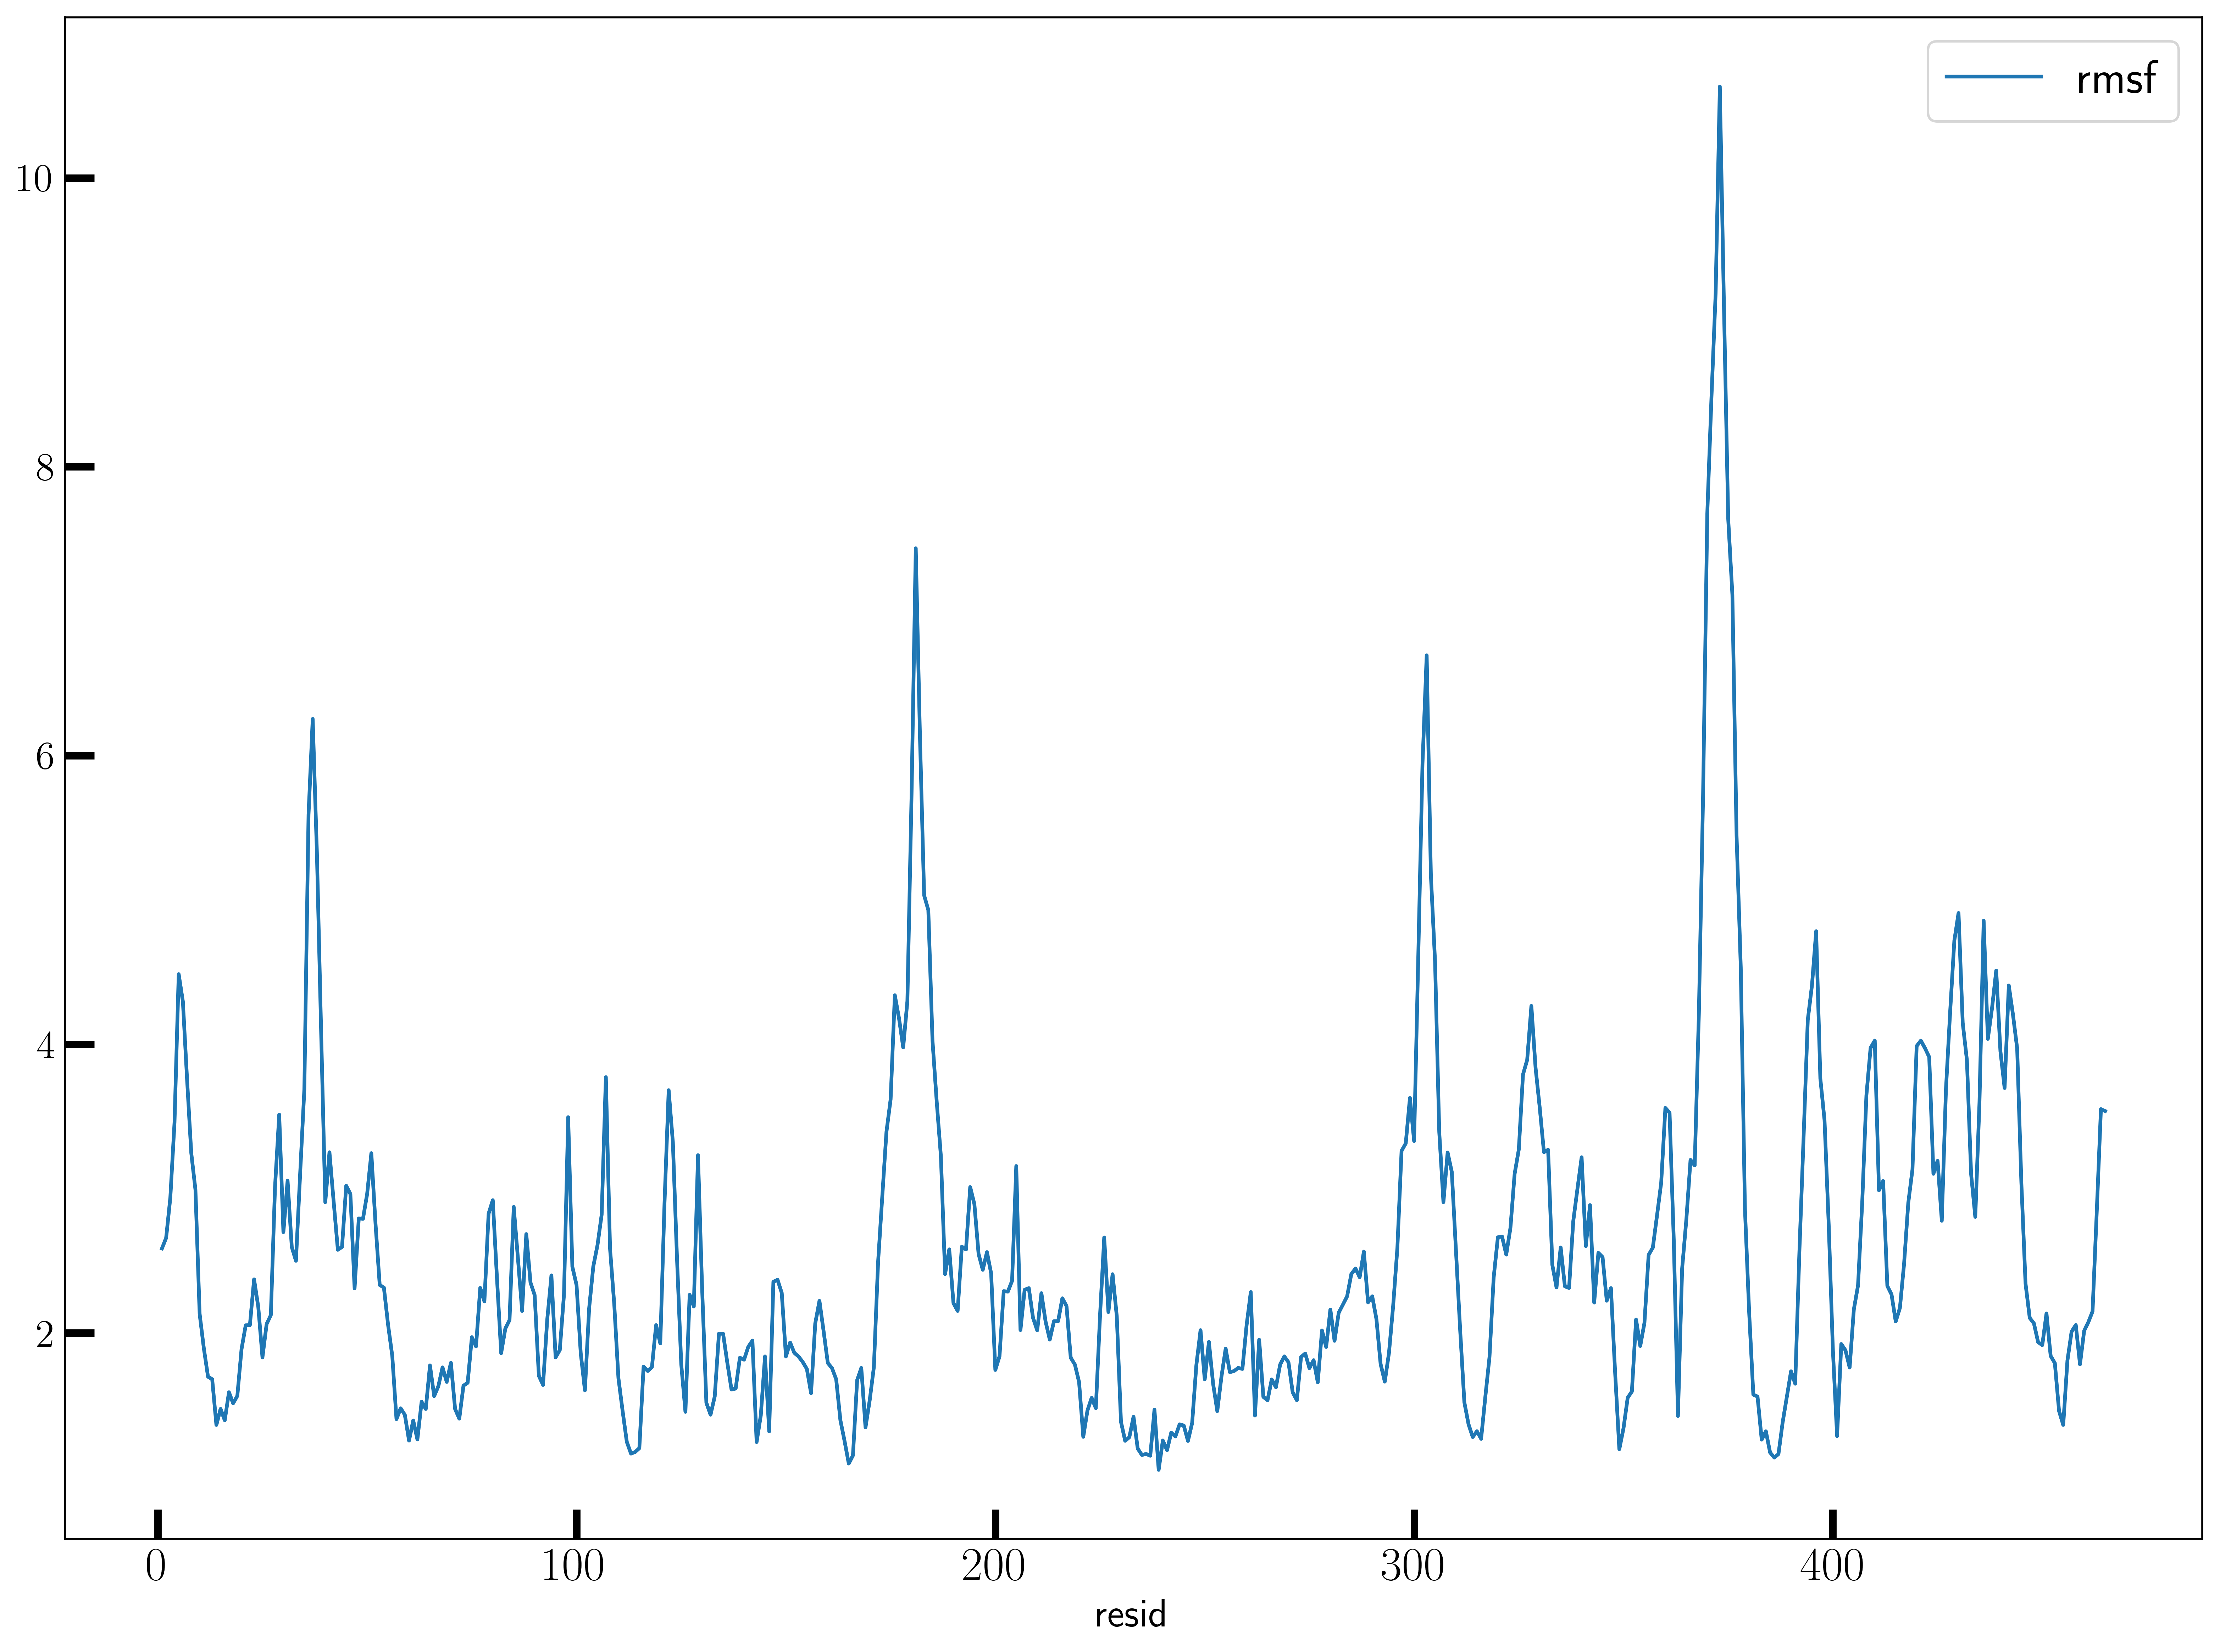

In [7]:
sel = complex.select_atoms('backbone and name CA')
R = rms.RMSF(sel).run(verbose=True)
resids = np.array(sel.resids)
rmsf = np.array(R.results.rmsf)

#Put these into the dataframe df. They may not be the same size as the other data, so pad them with NaNs
df['resid'] = np.nan
df['rmsf'] = np.nan
df.loc[:len(resids)-1, 'resid'] = resids
df.loc[:len(rmsf)-1, 'rmsf'] = rmsf
df.plot(x='resid', y='rmsf')


### Calculate all Radus of Gyration and load in the dataframe

In [8]:
from tqdm.notebook import tqdm
group = complex.select_atoms('protein')
times = []
rg = []
for ts in tqdm(complex.trajectory):
    times.append(ts.time)
    rg.append(group.radius_of_gyration())

  0%|          | 0/4002 [00:00<?, ?it/s]

In [9]:
df['time_rg'] = times
df['rg'] = rg # convert from Angstroms to nm
df

,time,rmsd,resid,rmsf,time_rg,rg
0,0.0,6.129725e-07,1.0,2.585335,0.0,23.038423
1,10.0,4.396733e+00,2.0,2.658652,10.0,24.603058
2,20.0,4.465314e+00,3.0,2.937515,20.0,24.259312
3,30.0,4.471830e+00,4.0,3.457495,30.0,24.218030
4,40.0,4.599914e+00,5.0,4.485538,40.0,24.152852
...,...,...,...,...,...,...
3997,39970.0,6.807420e+00,NaN,NaN,39960.0,25.546500
3998,39980.0,6.856128e+00,NaN,NaN,39970.0,25.687833
3999,39990.0,6.832017e+00,NaN,NaN,39980.0,25.646074
4000,40000.0,6.902604e+00,NaN,NaN,39990.0,25.638822


### Number of hydrogen bonds between protein and ligand

In [10]:
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA
import numpy as np
import pandas as pd

# I need to know the name of the protein residues that participate

# Strictly select protein and ligand atoms. Note that there is water in these trajectories for some reason...
protein = complex.select_atoms("protein")
ligand = complex.select_atoms("resname PDL")


# Create a selection consisting of palladium and explicitly n_atoms.indices
metal_nitrogens_selection = f"(name PD* or name Pd*) or (name N* and around 2.5 resname PDL)"

# 3. Create a selection of valid acceptors/donors
# We exclude the metal nitrogens from the global donor/acceptor pool. See ligand README for rationale.
valid_acceptors_sel = f"((resname PDL) and not ({metal_nitrogens_selection}))"
valid_donors_sel = "protein"
# Convert selection strings to AtomGroups to access .indices later
valid_acceptors = complex.select_atoms(valid_acceptors_sel)
valid_donors = complex.select_atoms(valid_donors_sel)

# Run HBA specifically for Protein (Donors) - Ligand (Acceptors)
hbs = HBA(universe=complex, donors_sel=valid_donors_sel, acceptors_sel=valid_acceptors_sel)
hbs.run(verbose=True)

# Run HBA specifically for Ligand (Donors) - Protein (Acceptors)
hbs_rev = HBA(universe=complex, donors_sel=valid_acceptors_sel, acceptors_sel=valid_donors_sel)
hbs_rev.run(verbose=True)

  0%|          | 0/4002 [00:00<?, ?it/s]

/usr/local/miniforge3/envs/biobb_wf_protein-complex_md_setup/lib/python3.12/site-packages/MDAnalysis/analysis/hydrogenbonds/hbond_analysis.py:775: UserWarning: No hydrogen bonds were found given angle of 150 between Donor, protein, and Acceptor, ((resname PDL) and not ((name PD* or name Pd*) or (name N* and around 2.5 resname PDL))).
  warnings.warn(
/usr/local/miniforge3/envs/biobb_wf_protein-complex_md_setup/lib/python3.12/site-packages/MDAnalysis/analysis/hydrogenbonds/hbond_analysis.py:743: UserWarning: No hydrogen bonds were found given d-a cutoff of 3.0 between Donor, protein, and Acceptor, ((resname PDL) and not ((name PD* or name Pd*) or (name N* and around 2.5 resname PDL))).
  warnings.warn(


  0%|          | 0/4002 [00:00<?, ?it/s]

/usr/local/miniforge3/envs/biobb_wf_protein-complex_md_setup/lib/python3.12/site-packages/MDAnalysis/analysis/hydrogenbonds/hbond_analysis.py:743: UserWarning: No hydrogen bonds were found given d-a cutoff of 3.0 between Donor, ((resname PDL) and not ((name PD* or name Pd*) or (name N* and around 2.5 resname PDL))), and Acceptor, protein.
  warnings.warn(
/usr/local/miniforge3/envs/biobb_wf_protein-complex_md_setup/lib/python3.12/site-packages/MDAnalysis/analysis/hydrogenbonds/hbond_analysis.py:775: UserWarning: No hydrogen bonds were found given angle of 150 between Donor, ((resname PDL) and not ((name PD* or name Pd*) or (name N* and around 2.5 resname PDL))), and Acceptor, protein.
  warnings.warn(


In [11]:
# Combine and identify protein residues
protein_residues = []
all_hbonds = np.vstack([hbs.results.hbonds, hbs_rev.results.hbonds])
valid_hbonds = []
for hb in all_hbonds:
    d_idx, a_idx = int(hb[1]), int(hb[3])
    # Identify which atom belongs to the protein
    if d_idx in valid_acceptors.indices and a_idx in valid_donors.indices:
        valid_hbonds.append(hb)
    elif a_idx in valid_acceptors.indices and d_idx in valid_donors.indices:
        valid_hbonds.append(hb)

for hb in valid_hbonds:
    d_idx, a_idx = int(hb[1]), int(hb[3])
    # Identify which atom belongs to the protein
    if d_idx in protein.indices:
        res = complex.atoms[d_idx].residue
        protein_residues.append(f"{res.resname}{res.resid}")
    elif a_idx in protein.indices:
        res = complex.atoms[a_idx].residue
        protein_residues.append(f"{res.resname}{res.resid}")

valid_hbonds = np.array(valid_hbonds)
print(f"Total H-bonds found: {len(valid_hbonds)}")

Total H-bonds found: 681


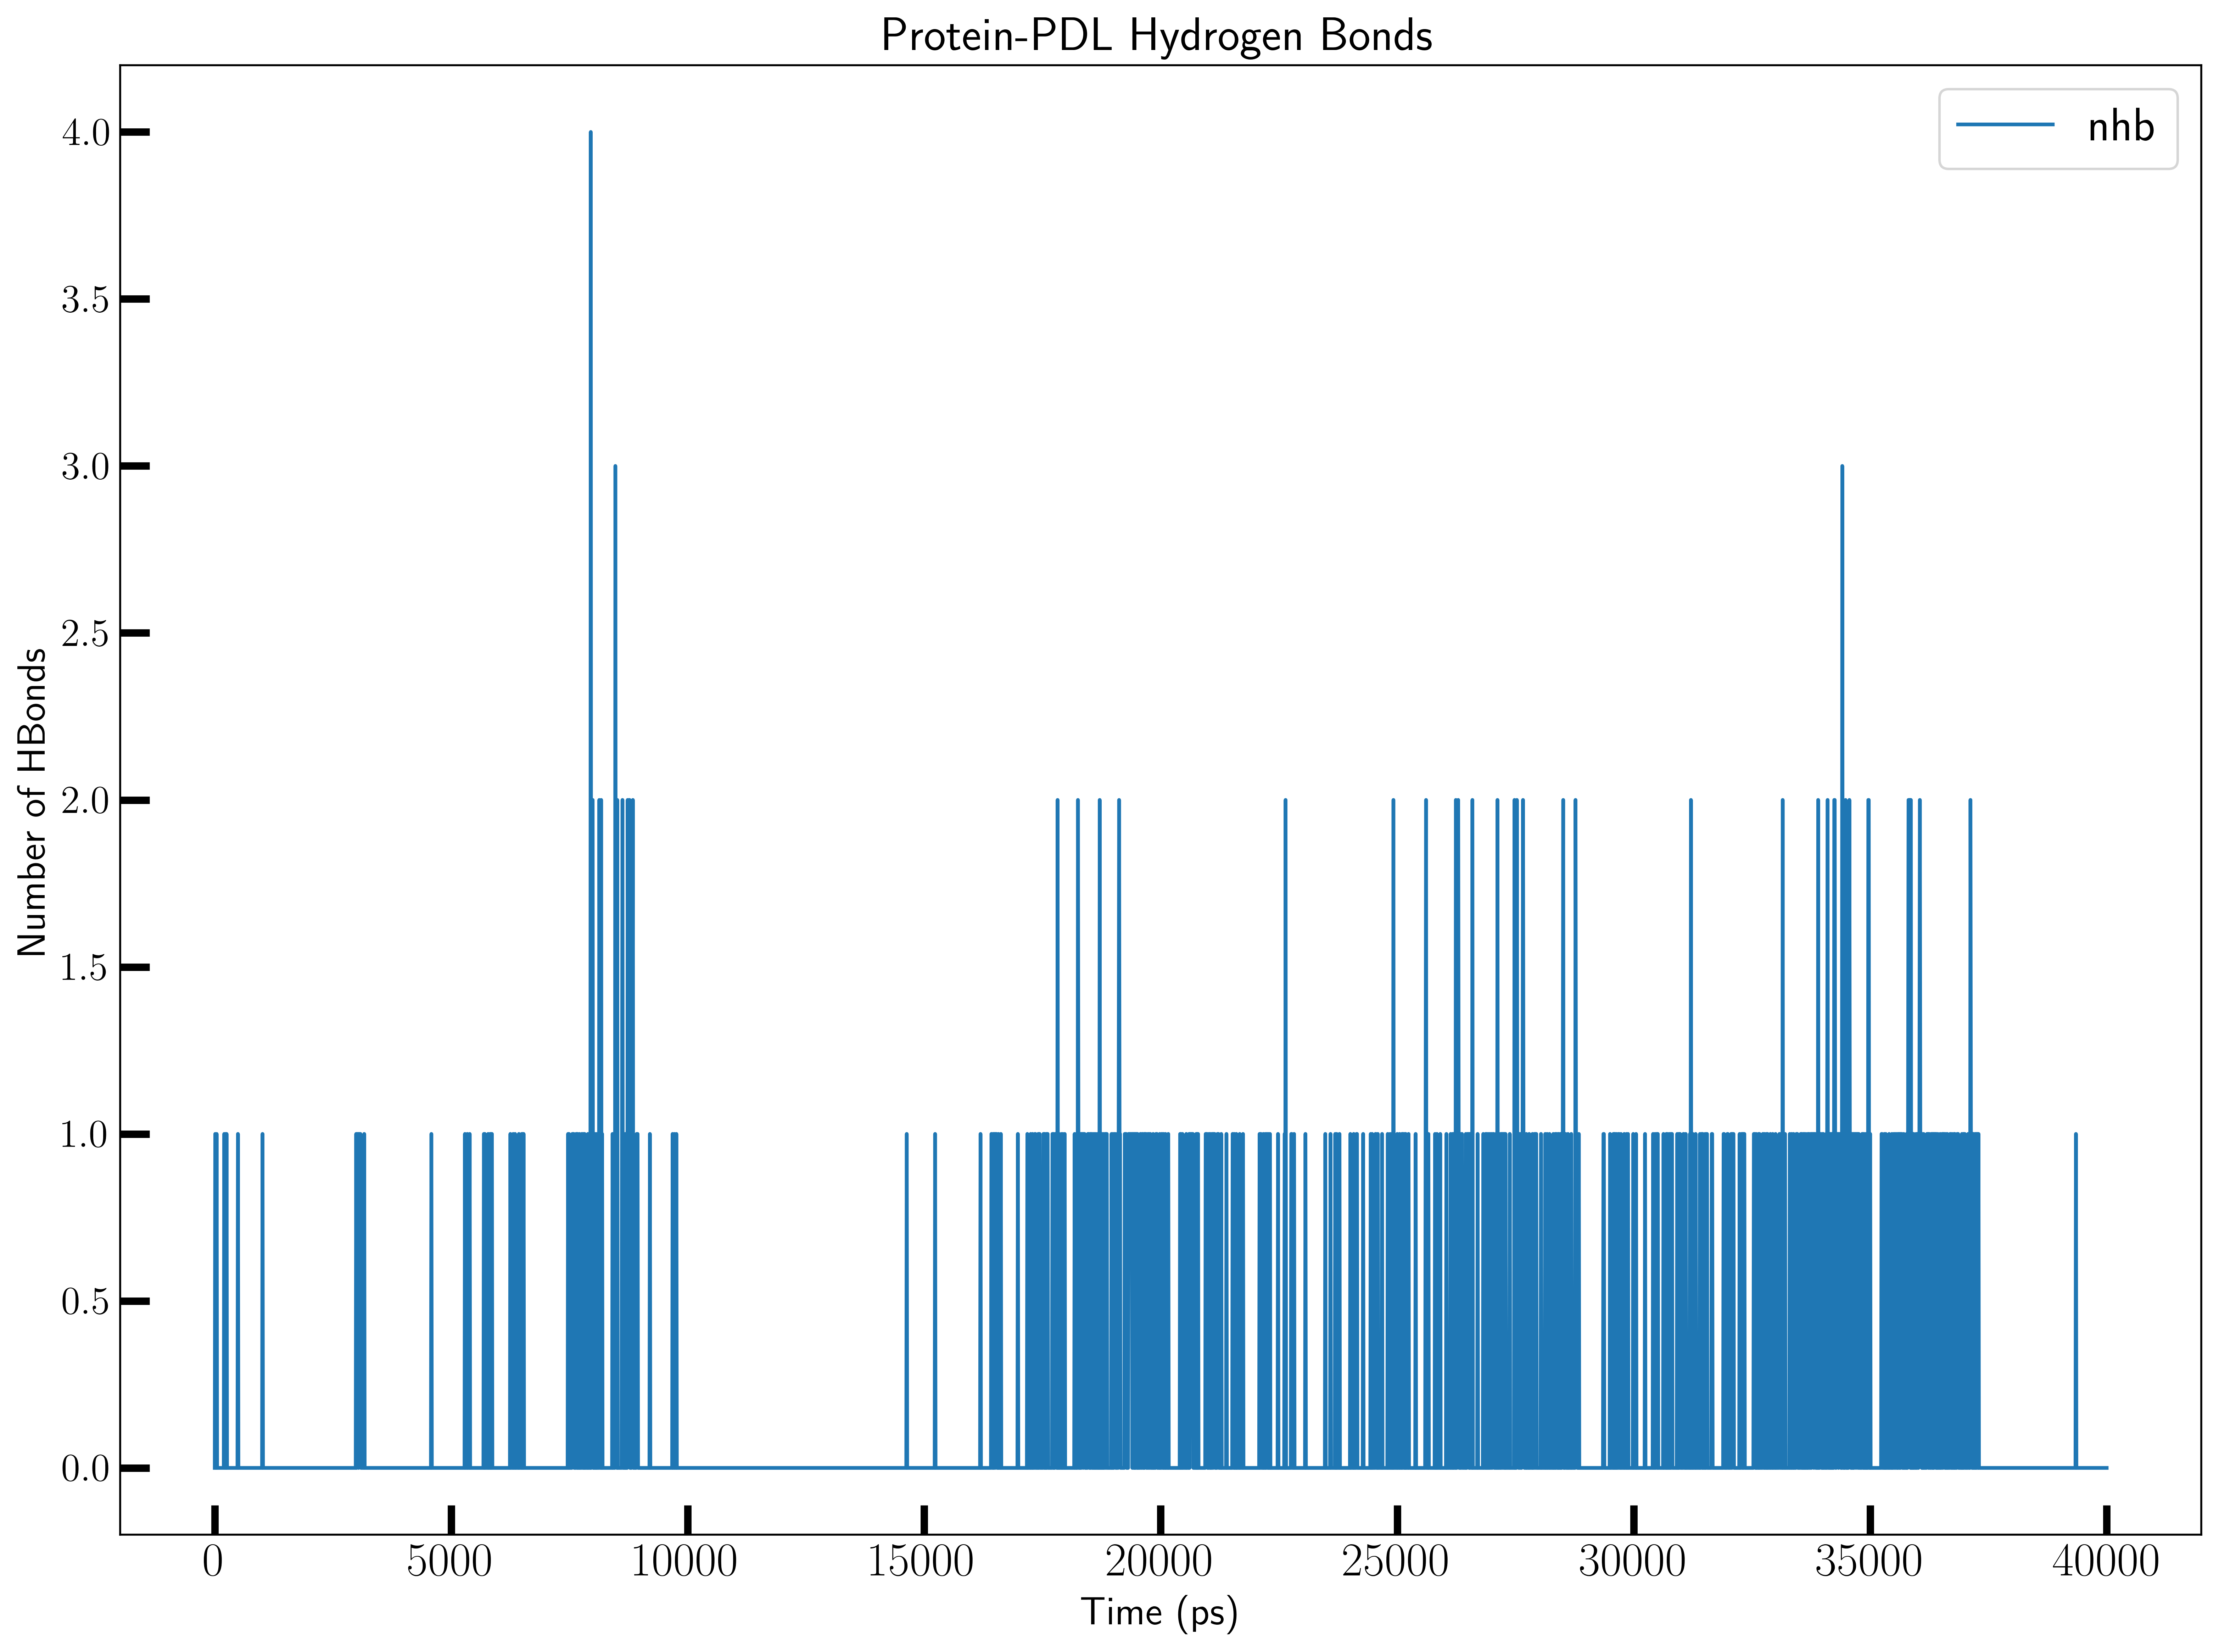

In [12]:
# Calculate counts per frame for the combined set
times = hbs.times
if valid_hbonds.size == 0:
    nhb = np.zeros_like(times, dtype=int)
else:
    frames = valid_hbonds[:, 0].astype(int)
    nhb = np.bincount(frames, minlength=len(times))[:len(times)]

# Create DataFrame and Plot
nhb_df = pd.DataFrame({'Time': times, 'nhb': nhb})
nhb_df.set_index('Time', inplace=True)
nhb_df.plot()
plt.xlabel('Time (ps)')
plt.ylabel('Number of HBonds')
plt.title('Protein-PDL Hydrogen Bonds')
plt.show()

### Plot everything

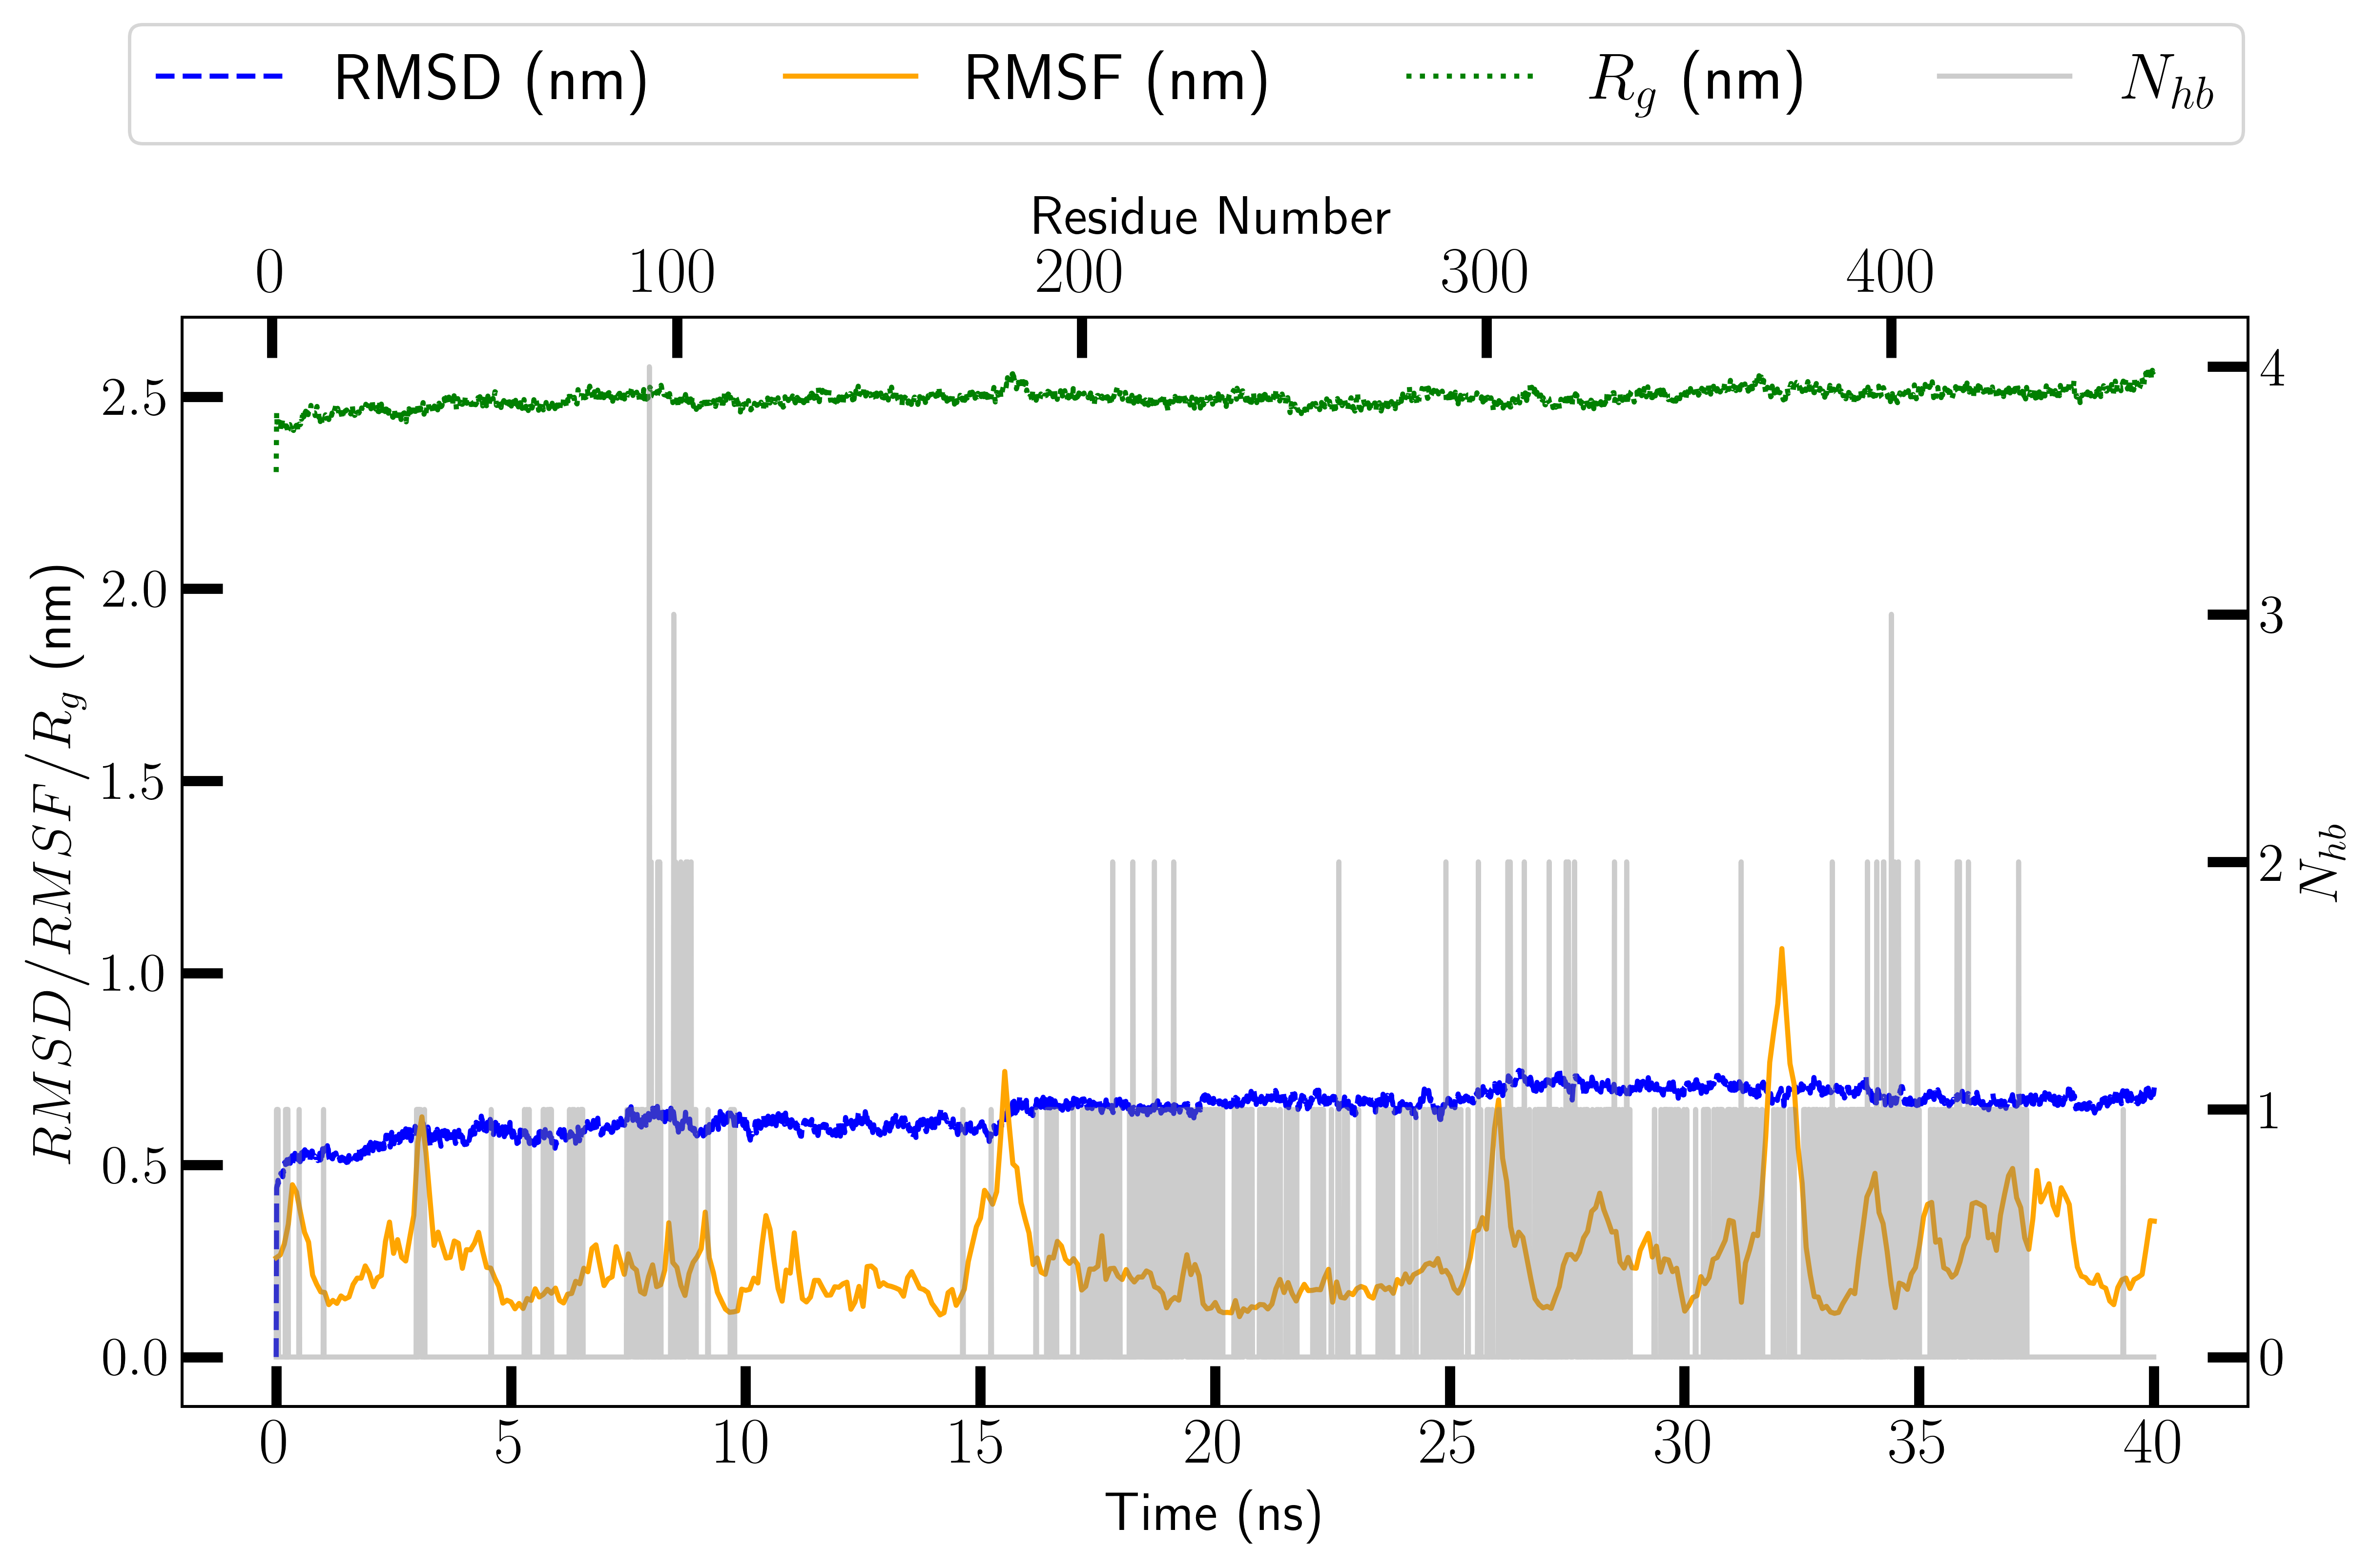

In [13]:
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(1, 1, figsize=(10, 6), sharey=True)


ax.set_xlabel('Time (ns)')
ax.set_ylabel(r"$RMSD\bigg/ RMSF \bigg/ R_g$ (nm)")
times = df['time']/1000 #Convert to nanoseconds
rmsd = df['rmsd']/10 # convert from Angstroms to nm
resids = np.array(df['resid'])
rmsf = np.array(df['rmsf'])
ax.plot(times, rmsd, color='blue', ls='dashed')
ax_top = ax.twiny()

ax_top.set_xlabel('Residue Number')
ymax = ax_top.get_ylim()[1]
ax_top.plot(resids, rmsf/10, color='orange', ls='solid')

times = np.array(df['time_rg'])/1000 #Convert to nanoseconds
rg = np.array(df['rg'])/10 # convert from Angstroms to nm
ax.plot(times, rg, color='green', ls=':')

ax_right = ax.twinx()
times = nhb_df.index.values/1000
ax_right.plot(times, nhb_df['nhb'], color='gray', alpha=0.4)
ax_right.set_ylim(-0.2, 4.2)
ax_right.yaxis.set_major_locator(MaxNLocator(integer=True))
ax_right.set_ylabel(r"$N_{hb}$")

line_rmsd = ax.lines[0]
line_rg = ax.lines[1]
line_rmsf = ax_top.lines[0]
line_nhb = ax_right.lines[0]
fig.legend([line_rmsd, line_rmsf, line_rg, line_nhb],
        ['RMSD (nm)', 'RMSF (nm)', r'$R_g$ (nm)', r'$N_{hb}$'],
        loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=4)

plt.savefig("rmsd_rmsf_rg_nhb_scaled8.svg", dpi=300, bbox_inches='tight')

## Distance metrics

In [14]:
# Calculate and plot the distance between the center of mass of the ligand and the center of mass of the protein
from MDAnalysis.analysis import distances
from tqdm.notebook import tqdm
import numpy as np
import pandas as pd

protein_com = complex.select_atoms('protein').center_of_mass()
ligand_com = complex.select_atoms('resname PDL').center_of_mass()
times = []
dists = []

for ts in tqdm(complex.trajectory):
    protein_com = complex.select_atoms('protein').center_of_mass()
    ligand_com = complex.select_atoms('resname PDL').center_of_mass()
    dist = distances.distance_array(protein_com, ligand_com)
    times.append(ts.time)
    dists.append(dist[0][0])
times = np.array(times)/1000 #Convert to nanoseconds
dists = np.array(dists)/10 # convert from Angstroms to nm

# Create a pandas dataframe
dist_df = pd.DataFrame({'time': times, 'distance': dists})


  0%|          | 0/4002 [00:00<?, ?it/s]

In [17]:
import re

binding_residues = set(protein_residues)

# Pre-select AtomGroups for each binding residue to improve performance
res_selections = {}
for res in binding_residues:
    # Use regex to split "HIS60" into "HIS" and "60"
    match = re.match(r"([a-zA-Z]+)([0-9]+)", res)
    if match:
        resname, resid = match.groups()
        res_selections[res] = complex.select_atoms(f"resname {resname} and resid {resid}")

# Calculate the distance between the ligand COM and each of the binding residues (COMs) over time
binding_dists = pd.DataFrame({'time': times})
for res in binding_residues:
    binding_dists[res] = np.nan

for ts in tqdm(complex.trajectory):
    time_ns = ts.time / 1000
    ligand_com = ligand.center_of_mass()
    
    # Use a dictionary to collect data for the current frame
    frame_data = {'time': time_ns}
    for res, res_sel in res_selections.items():
        res_com = res_sel.center_of_mass()
        dist = distances.distance_array(ligand_com, res_com)
        binding_dists.loc[binding_dists['time'] == time_ns, res] = dist[0][0] / 10 # convert from Angstroms to nm


  0%|          | 0/4002 [00:00<?, ?it/s]

In [18]:
binding_dists

,time,VAL159,SER153,HIS60,HIS165,PRO248,VAL162,TRP127,ALA149,ALA229,VAL163,ILE151,ASN150,GLU369,GLN365,ARG366
0,0.00,1.310207,2.077812,2.296729,0.860825,0.833889,0.909915,0.800163,1.515475,1.058715,1.115159,1.672990,1.297818,2.383722,2.135189,2.315779
1,0.01,0.958602,1.628188,2.054285,0.924307,0.982154,0.727831,1.248787,1.175450,0.867497,0.734623,1.617803,1.334401,1.794138,1.571142,1.390224
2,0.02,0.958885,1.527983,1.860278,0.893788,1.050310,0.708103,1.148306,0.932082,1.017512,0.737731,1.442093,1.054453,1.560091,1.445358,1.093140
3,0.03,1.062845,1.545286,1.858324,0.949887,1.115370,0.697176,1.182377,0.858735,0.970571,0.773062,1.390336,1.011334,1.615789,1.538590,1.188998
4,0.04,1.127470,1.648217,1.887399,0.920459,1.047326,0.783570,1.106409,0.925811,0.999262,0.816797,1.473013,1.089357,1.570049,1.511723,1.177947
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3997,39.96,0.869463,0.645741,1.151787,1.492298,0.893969,0.868828,2.235890,1.195415,1.665782,0.794611,0.936007,1.084448,1.182798,0.671113,0.726971
3998,39.97,0.908341,0.678107,1.205554,1.527223,0.831011,0.899830,2.234379,1.177983,1.711208,0.822879,0.894527,0.985042,1.231421,0.712976,0.767755
3999,39.98,0.855537,0.696042,1.193235,1.466846,0.940066,0.869214,2.239624,1.191077,1.650095,0.776199,0.953577,1.092448,1.249535,0.702223,0.744060
4000,39.99,0.801706,0.738089,1.199340,1.510243,0.864932,0.847867,2.298322,1.258078,1.686937,0.849608,0.972878,1.137122,1.275715,0.714125,0.746522


In [ ]:
from tabulate import tabulate
# Use tabulate to prepare a list of all valid hbonds, including the donor, hydrogen and acceptor atoms and resids
# Only unique hbonds should be listed, so we can use a set to track them
hbond_set = set()
for hb in valid_hbonds:
    d_idx, a_idx = int(hb[1]), int(hb[3])
    d_atom = complex.atoms[d_idx]
    a_atom = complex.atoms[a_idx]
    hbond_tuple = (f"{d_atom.resname}{d_atom.resid}:{d_atom.name}", f"{a_atom.resname}{a_atom.resid}:{a_atom.name}")
    if hbond_tuple not in hbond_set:
        hbond_set.add(hbond_tuple)
        
# Combine the cases where the protein residue is the same, even if the participating atom is different.
binding_residues = set()
for hbond in hbond_set:
    donor, acceptor = hbond
    if donor.startswith("PDL"):
        binding_residues.add(acceptor.split(":")[0]) # Add the residue name and number, but not the atom name
    elif acceptor.startswith("PDL"):
        binding_residues.add(donor.split(":")[0]) # Add the residue name and number, but not the atom name

# Sort using regex to extract digits correctly
import re
binding_residues = sorted(binding_residues, key=lambda x: int(re.search(r'\d+', x).group()))

print("Binding residues identified from H-bonds:")
print(tabulate([[res] for res in binding_residues], headers=["Residue"], tablefmt="grid"))

Binding residues identified from H-bonds:
+-----------+
| Residue   |
+===========+
| HIS60     |
+-----------+
| TRP127    |
+-----------+
| ALA149    |
+-----------+
| ASN150    |
+-----------+
| ILE151    |
+-----------+
| SER153    |
+-----------+
| VAL159    |
+-----------+
| VAL162    |
+-----------+
| VAL163    |
+-----------+
| HIS165    |
+-----------+
| ALA229    |
+-----------+
| PRO248    |
+-----------+
| GLN365    |
+-----------+
| ARG366    |
+-----------+
| GLU369    |
+-----------+


In [22]:
# Sort binding residues in increasing order og residue id
import re
binding_residues = sorted(binding_residues, key=lambda x: int(re.search(r'\d+', x).group()))

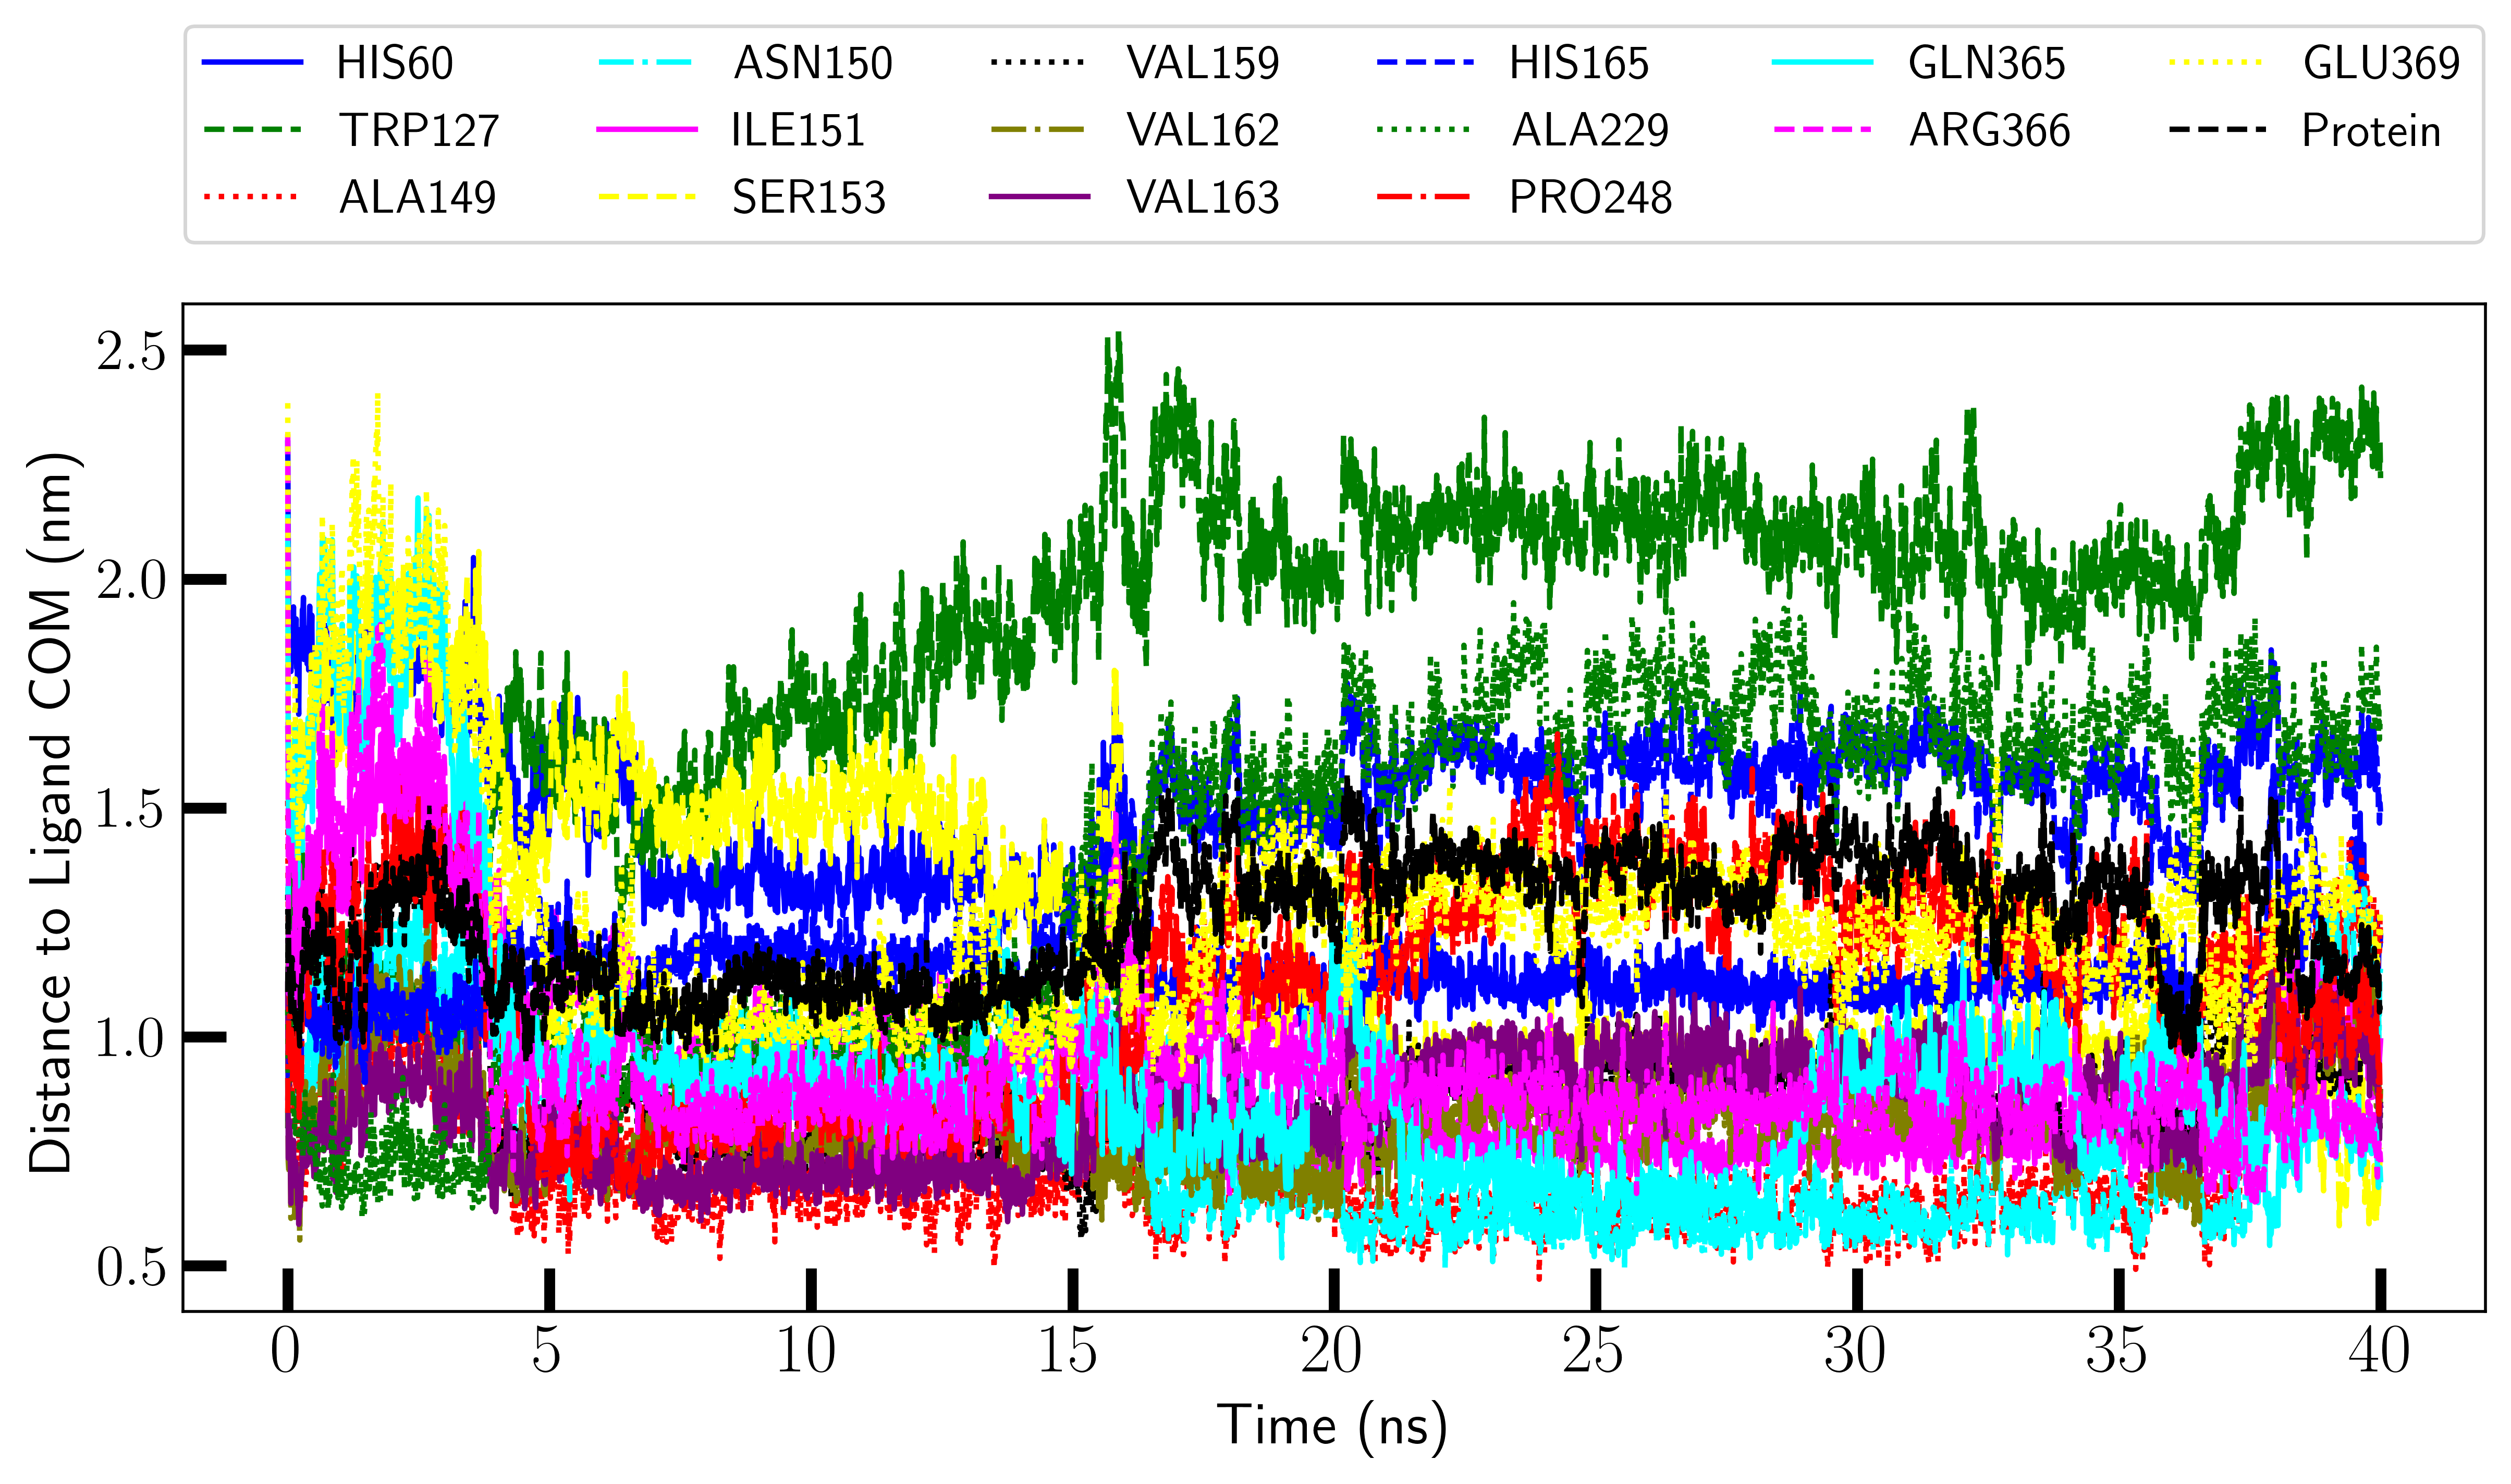

In [30]:
# Now, plot them
from itertools import cycle
plt.figure(figsize=(10, 6))

# I need 16 color-linstyle pairs
colors = cycle(['blue', 'green', 'red', 'cyan', 'magenta', 'yellow', 'black', 'olive', 'purple'])
line_styles = cycle(['-', '--', ':', '-.'])

for res in binding_residues:
    plt.plot(binding_dists['time'], binding_dists[res], label=res, color=next(colors), ls=next(line_styles))
plt.xlabel('Time (ns)')
plt.ylabel('Distance to Ligand COM (nm)')
plt.ylim(0.4, 2.6)
#Add the plot for the ligand-protein COM distance
plt.plot(dist_df['time'], dist_df['distance'], label='Protein', color='black', ls='--')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=6, fontsize='small')
plt.savefig("binding_distances_scaled8.svg", dpi=300, bbox_inches='tight')
plt.show()

## Hydrogen Bond Occupancy Statistics

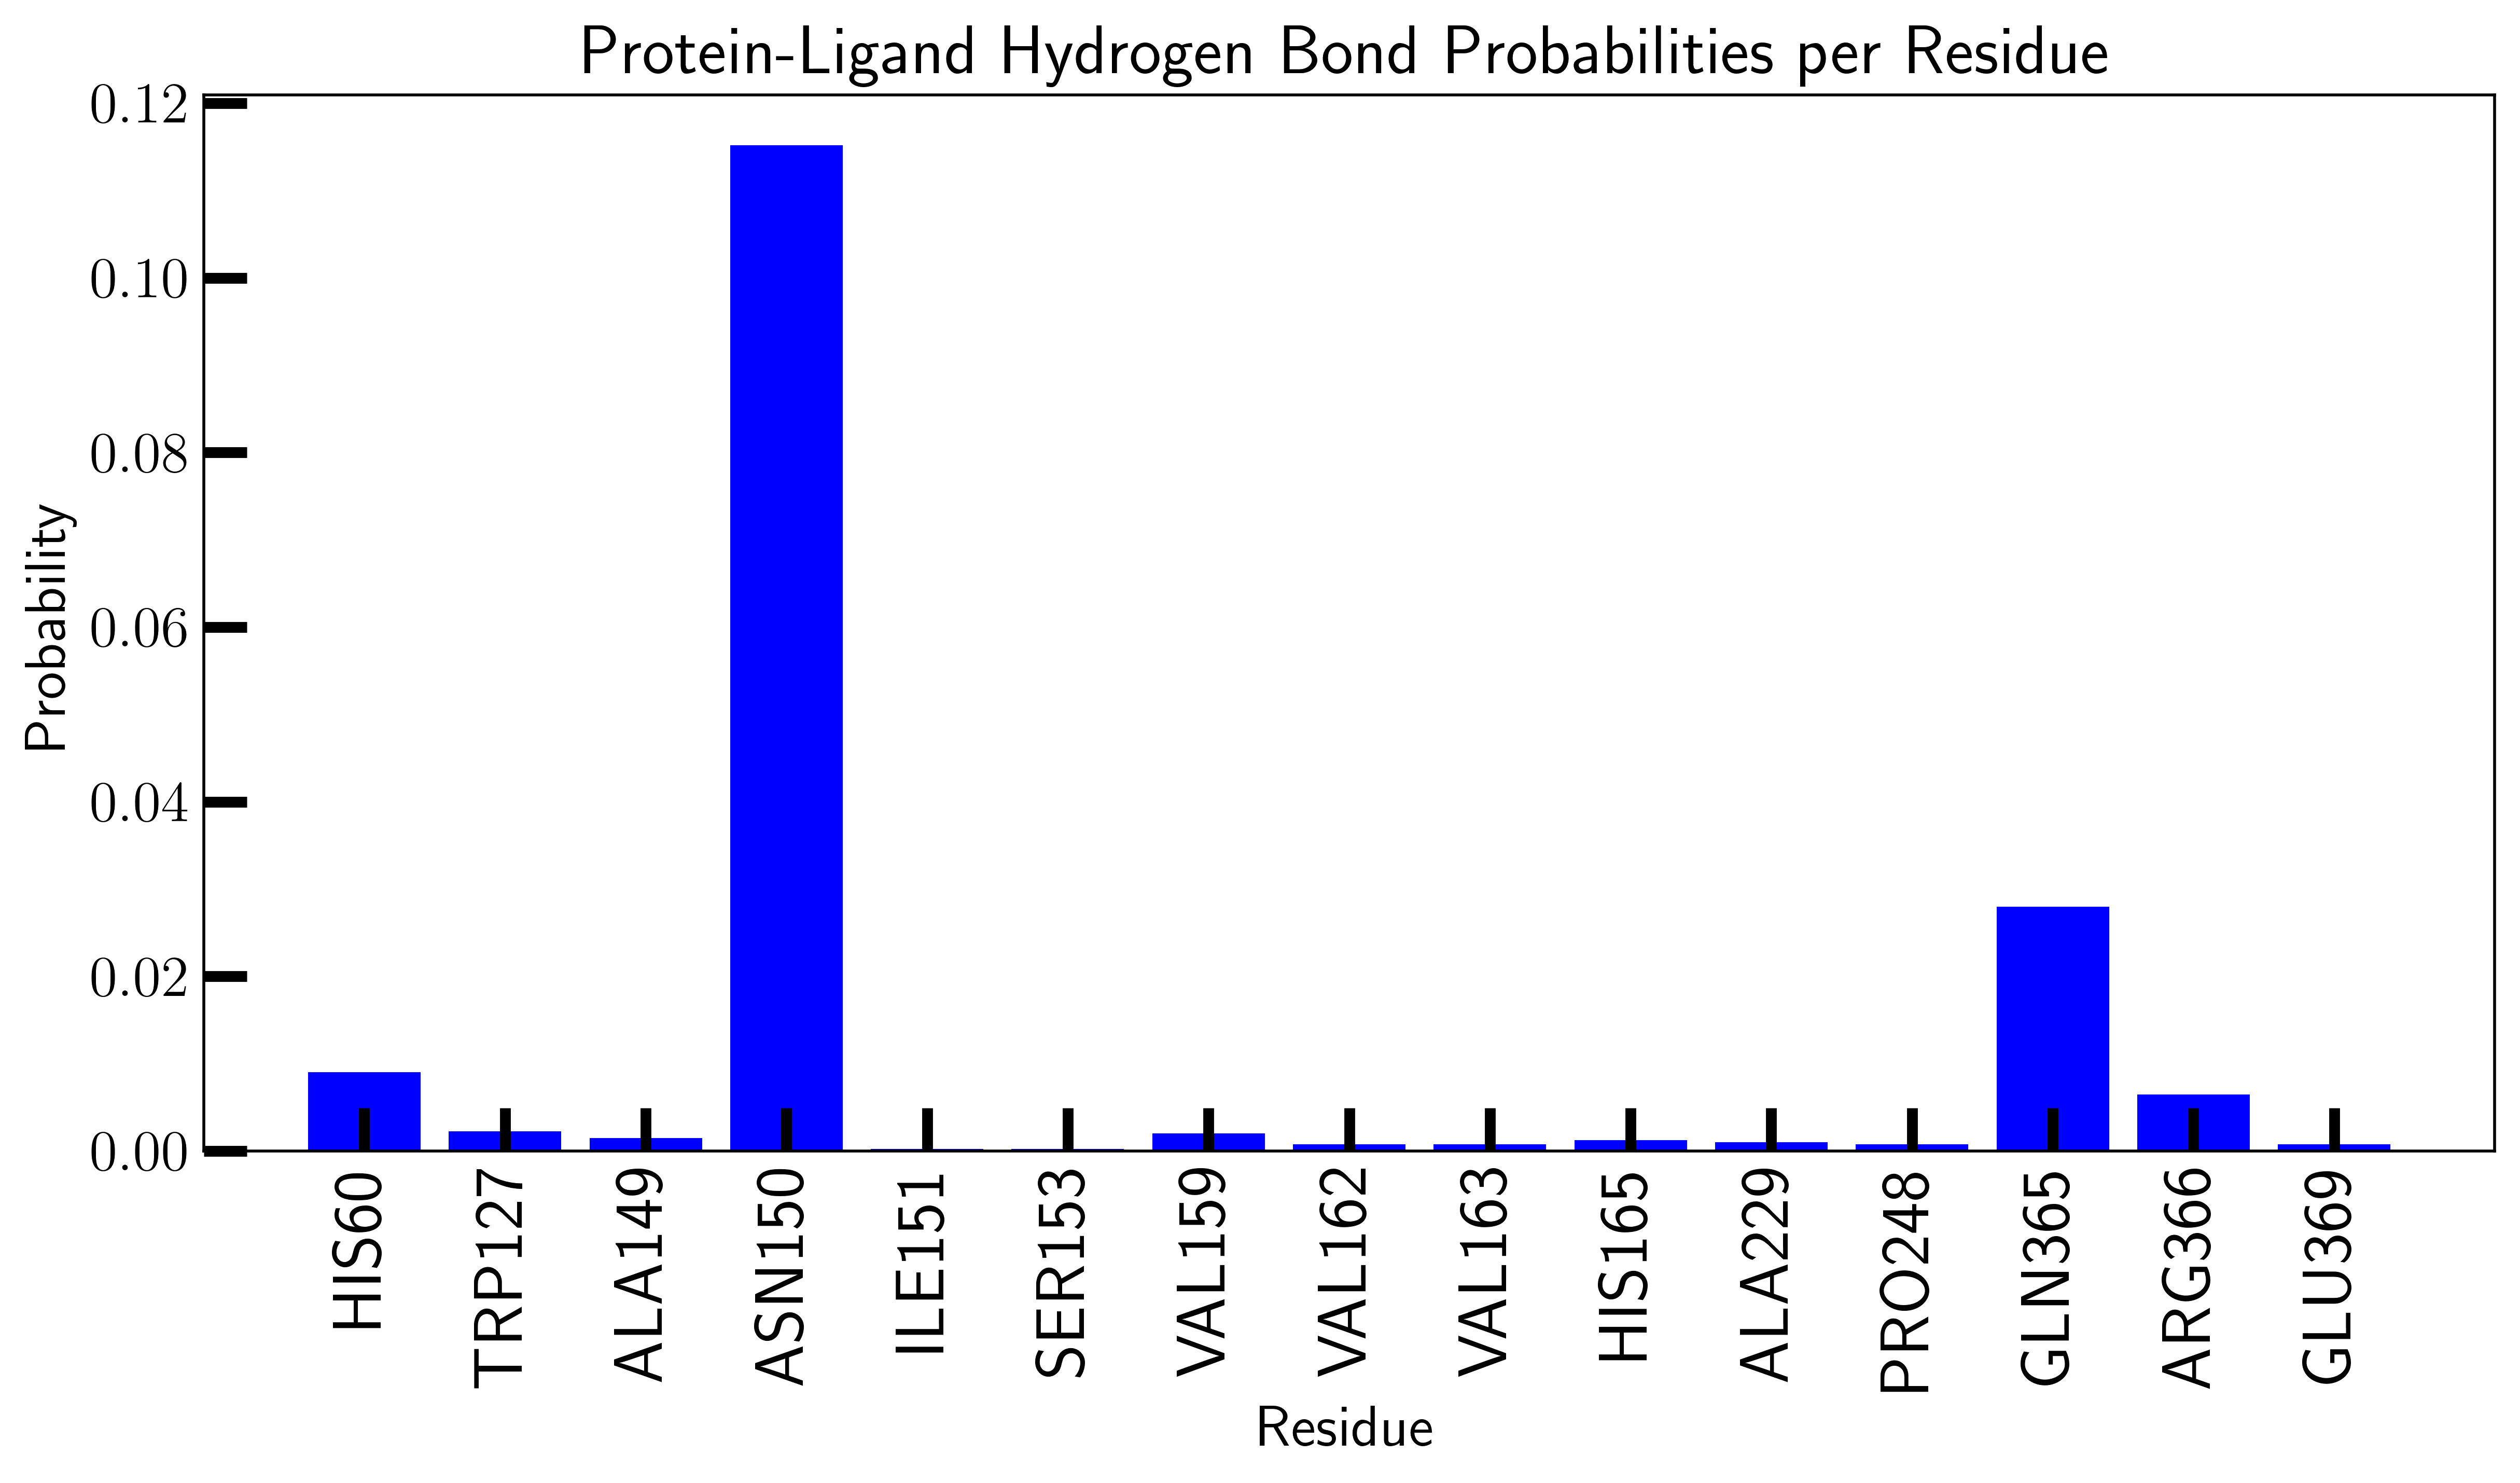

In [32]:
# Estimate the hydrogen bond probabilities (total number of frames with a given number of H-bonds divided by total number of frames) per participating residue and plot in a histogram. The x-axis contains the participating residues and the y-axis contains the probabilities. The title of the plot is "Hydrogen Bond Probabilities per Residue". The bars are colored in blue.
from collections import Counter
import matplotlib.pyplot as plt
import re
residue_counts = Counter(protein_residues)
total_frames = len(complex.trajectory)
residue_probabilities = {res: count/total_frames for res, count in residue_counts.items()}
plt.figure(figsize=(10, 6))
# Sort the x-axis of the histogram by residue number. The residue names are in the format "RESID123", so we can extract the number and sort by it.
residues_sorted = sorted(residue_probabilities.keys(), key=lambda x: int(re.search(r'\d+', x).group()))
probabilities_sorted = [residue_probabilities[res] for res in residues_sorted]
plt.bar(residues_sorted, probabilities_sorted, color='blue')
plt.xlabel('Residue')
plt.ylabel('Probability')
plt.title('Protein-Ligand Hydrogen Bond Probabilities per Residue')
plt.xticks(rotation=90)
plt.savefig("hbond_probabilities_scaled8.svg", dpi=300, bbox_inches='tight')
plt.show()

## Proper PDB snapshots with correct bonds

In [33]:
# Dump pdb snapshots to disc of start, 1ns, 5ns and 10ns, with all bonds in topology saved as conect records. Include only protein, PDL and Zinc
snapshot_times = [0, 1000, 5000, 10000] # in picoseconds
dt = complex.trajectory.dt
snapshot_indices = [int(t / dt) for t in snapshot_times]
for idx, time in zip(snapshot_indices, snapshot_times):
    complex.trajectory[idx] # Move to the desired frame
    # Include resname Zn or ZN
    snapshot = complex.select_atoms("protein or resname PDL or name PD* or name Pd* or resname Zn or resname ZN")
    snapshot.write(f"snapshot_{time}ps.pdb", bonds='conect')

/usr/local/miniforge3/envs/biobb_wf_protein-complex_md_setup/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'altLocs' Using default value of ' '
  warnings.warn("Found no information for attr: '{}'"
/usr/local/miniforge3/envs/biobb_wf_protein-complex_md_setup/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'icodes' Using default value of ' '
  warnings.warn("Found no information for attr: '{}'"
/usr/local/miniforge3/envs/biobb_wf_protein-complex_md_setup/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'occupancies' Using default value of '1.0'
  warnings.warn("Found no information for attr: '{}'"
/usr/local/miniforge3/envs/biobb_wf_protein-complex_md_setup/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'tempfactors' Using default value of '0.0'